In [1]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub

In [2]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.1 MB/s eta 0:00:00


In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-05-20 16:11:12.601345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779293473.015191      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779293473.132391      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779293474.124812      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779293474.124870      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779293474.124873      23 computation_placer.cc:177] computation placer alr

In [4]:
# Cài đặt wrapper Python cho VnCoreNLP.
!pip install vncorenlp

# Tải xuống VnCoreNLP và thành phần phân đoạn từ (RDRSegmenter).
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=16efec8be5937427b26b241cabd812639f2857a5c131b285bcc583c11d43c99e
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
--2026-05-20 16:12:16--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M   160MB/s    in 0.2s    

2026-05-20 16:12:17 (160 MB/s) - ‘VnCoreNLP

In [5]:
from vncorenlp import VnCoreNLP
# Khởi tạo RDRSegmenter từ VnCoreNLP để phân đoạn từ tiếng Việt.
rdrsegmenter = VnCoreNLP(
    "vncorenlp/VnCoreNLP-1.1.1.jar", 
    annotators="wseg", 
    max_heap_size='-Xmx500m')

text = "thầy nhiệt tình giảng dạy, gần gũi với sinh viên"

# Phân đoạn từ cho đoạn văn bản tiếng Việt.
word_segmented_text = rdrsegmenter.tokenize(text)
print(word_segmented_text)

[['thầy', 'nhiệt_tình', 'giảng_dạy', ',', 'gần_gũi', 'với', 'sinh_viên']]


In [6]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

TRAIN_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/train_final.csv"
VAL_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/val_final.csv"
TEST_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/test_final.csv"


# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

def load_data_from_csv():
    try:
        # Load file đã cập nhật nhãn
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df1 = pd.read_csv(TEST_PATH)
        
        print("--- Thông tin dữ liệu đã load ---")
        print(f"Tập Train: {len(train_df)} mẫu")
        print(f"Tập Val  : {len(val_df)} mẫu")
        print(f"Tập Test  : {len(test_df1)} mẫu")
        
        
        # return train_df, val_df, test_df1
        return test_df1
    
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. Hãy chắc chắn bạn đã chạy bước xuất CSV trước đó. \nChi tiết: {e}")
        return None, None

# 2. Thực thi load dữ liệu
# train_df, val_df, test_df1 = load_data_from_csv()
test_df1 = load_data_from_csv()

--- Thông tin dữ liệu đã load ---
Tập Train: 11426 mẫu
Tập Val  : 1583 mẫu
Tập Test  : 3166 mẫu


In [7]:
train_df

,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1
11422,em cảm ơn cô nhiều .,2,0
11423,giao bài tập quá nhiều .,0,0
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0


# Preprocessing

In [ ]:
def load_external_teencode(file_path):
    """Hàm đọc file teencode.txt từ Kaggle và chuyển thành Dictionary"""
    external_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Thông thường file teencode.txt trên Kaggle phân tách bằng dấu Tab (\t)
                # Nếu file dùng định dạng khác (như dấu phẩy), hãy đổi split('\t') thành split(',')
                parts = line.strip().split('\t') 
                if len(parts) >= 2:
                    teencode = parts[0].strip().lower()
                    standard = parts[1].strip().lower()
                    external_dict[teencode] = standard
        print(f"Đã tải thành công {len(external_dict)} từ teencode từ file Kaggle.")
    except Exception as e:
        print(f"Lỗi khi đọc file teencode: {e}")
    return external_dict

# Từ điển giải mã Emoticon đặc thù của dữ liệu UIT-VSFC
UIT_VSFC_EMOTICON_DICT = {
    "colonsmilesmile": "rất vui", "colondoublesurprise": "rất bất ngờ",
    "colonbigsmile": "cười to", "colonsadcolon": "rất buồn",
    "colonsmalsmile": "mỉm cười", "colonsmile": "vui vẻ",
    "colonlove": "yêu thích", "colonsad": "buồn bã",
    "colonhihi": "vui vẻ", "coloncontemn": "chê bai",
    "coloncolon": "bối rối" 
}

# Từ điển tự định nghĩa (Mang tính cục bộ của môi trường đại học)
CUSTOM_TEENCODE_DICT = {
    "ko": "không", "k": "không", "kh": "không", "khg": "không", "kg": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "sv": "sinh viên", "gv": "giảng viên", "thầy cô": "giảng viên",
    "vs": "với", "r": "rồi", "ah": "à", "nhìu": "nhiều",
    "bt": "bình thường", "tot": "tốt", "thik": "thích", 
    "ntn": "như thế nào", "nv": "nhân viên", "cs vc": "cơ sở vật chất",
    "csvc": "cơ sở vật chất", "wifi": "mạng", "phong": "phòng", "vkl": "vô cùng",
    "vl": "vô cùng", "vcl": "vô cùng", "đm": "chửi thề", "vãi": "rất"
}

# Tiến hành hợp nhất 2 từ điển
KAGGLE_FILE_PATH = '/kaggle/input/datasets/taiduong1/vietnamese-teencode/teencode.txt'

# Bước 1: Load file gốc
FINAL_TEENCODE_DICT = load_external_teencode(KAGGLE_FILE_PATH)

# Bước 2: Dùng lệnh .update() để hợp nhất. 
# Từ điển CUSTOM sẽ ghi đè lên EXTERNAL nếu có các key trùng lặp.
FINAL_TEENCODE_DICT.update(CUSTOM_TEENCODE_DICT)

print(f"Tổng số từ khóa teencode hiện có trong bộ lọc: {len(FINAL_TEENCODE_DICT)}")

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Dùng thư viện ngoài để chuẩn hóa Unicode
    text = text_normalize(text).lower()
    
    # 2. Giải mã các chuỗi emoticon đặc thù
    for encoded_emo, meaning in UIT_VSFC_EMOTICON_DICT.items():
        text = re.sub(r'\b' + re.escape(encoded_emo) + r'\b', f" {meaning} ", text)
        
    # 3. Chuẩn hóa Teencode bằng TỪ ĐIỂN ĐÃ HỢP NHẤT
    for word, true_word in FINAL_TEENCODE_DICT.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', f" {true_word} ", text)
        
    # 4. Loại bỏ dấu câu (Punctuation)
    punctuations = string.punctuation + '”’“‘…—'
    for p in punctuations:
        text = text.replace(p, ' ')
        
    # 5. Loại bỏ kí tự rác (Chỉ giữ chữ cái tiếng Việt, số, khoảng trắng)
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    
    # 6. Chuẩn hóa khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df['cleaned_text'] = train_df['sentence'].apply(clean_vietnamese_text)
val_df['cleaned_text'] = val_df['sentence'].apply(clean_vietnamese_text)
test_df['cleaned_text'] = test_df['sentence'].apply(clean_vietnamese_text)
test_df1['cleaned_text'] = test_df1['sentence'].apply(clean_vietnamese_text)

Đã tải thành công 389 từ teencode từ file Kaggle.
Tổng số từ khóa teencode hiện có trong bộ lọc: 406


# Segment toàn bộ dataset

In [ ]:
def word_segment(text):
    if not isinstance(text, str):
        return ""
    try:
        tokens = rdrsegmenter.tokenize(text)
        return " ".join([w for sent in tokens for w in sent])
    except Exception:
        return text

train_df['sentence_seg'] = train_df['cleaned_text'].apply(word_segment)
val_df['sentence_seg'] = val_df['cleaned_text'].apply(word_segment)
test_df['sentence_seg'] = test_df['cleaned_text'].apply(word_segment)
test_df1['sentence_seg'] = test_df1['cleaned_text'].apply(word_segment)

train_df.head()

,sentence,sentiment,topic,cleaned_text,sentence_seg
0,slide giáo trình đầy đủ .,2,1,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,0,1,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full điểm chuyên_cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,thầy giảng bài hay có nhiều bài tập ví dụ ngay...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...


# B1a MTL Hard Sharing + CE
# B2a MTL Cross Attention + CE
# B3a MTL Soft Sharing + CE
# B4a MTL MMoE + CE
# B5a MTL Hard Sharing + PCGrad + CE
# B6a MTL Soft Sharing + PCGrad + CE

In [ ]:
# config
MODEL_NAME   = "vinai/phobert-base"
MAX_LEN      = 128
BATCH_SIZE   = 32
ACCUM_STEPS  = 1
LR           = 2e-5
LR_ENCODER   = 2e-5   
LR_HEADS     = 1e-4   # LR cho Classification Heads và Cross-Attention
DROPOUT      = 0.3   
EPOCHS       = 20
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
PATIENCE      = 5       
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

# Tên nhãn dùng nhất quán trong toàn bộ file
SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training Program", "Facility", "Others"]
 
print(f"Device : {DEVICE}")
print(f"Encoder: {MODEL_NAME}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }

def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        # df["sentence"].tolist(),
        df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)
test_loader1  = make_loader(test_df1,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Test relabled: {len(test_df1)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)

sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test cho MTL
def diagnose_validation(model, val_loader, model_name):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số"""
    model.eval()
    s_preds, s_labels, t_preds, t_labels = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            s_logit, t_logit = model(ids, mask)
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    print(f"\nChấn đoán trên validation === {model_name} ===")
    print("SENTIMENT:")
    print(classification_report(s_labels, s_preds, target_names=["Negative", "Neutral", "Positive"], digits=4))
    print("TOPIC:")
    print(classification_report(t_labels, t_preds, target_names=["Lecturer", "Training", "Facility", "Others"], digits=4))

# Chẩn đoán trên tập val trước khi lưu test cho Single-Task
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device : cuda
Encoder: vinai/phobert-base


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 11426 | Val: 1583 | Test: 3166 | Test relabled: 3166
Sentiment weights: tensor([0.2210, 2.5700, 0.2090])
Topic weights    : tensor([0.1120, 0.4160, 1.8420, 1.6290])
Focal alpha  (sentiment): [0.0737 0.8568 0.0695]
Focal alpha  (topic)    : [0.028  0.104  0.4606 0.4073]


In [ ]:
# Hard Sharing 
class MTLHardSharing(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.sent_head(cls), self.topic_head(cls)

# Cross-Task Attention
class CrossTaskAttention(nn.Module):
    def __init__(self, hidden_size, num_heads=4, dropout=0.3):
        super().__init__()
        self.attn_s2t = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.attn_t2s = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.norm_s   = nn.LayerNorm(hidden_size)
        self.norm_t   = nn.LayerNorm(hidden_size)

    def forward(self, sent_repr, topic_repr):
        s_refined, _ = self.attn_s2t(sent_repr.unsqueeze(1), topic_repr.unsqueeze(1), topic_repr.unsqueeze(1))
        t_refined, _ = self.attn_t2s(topic_repr.unsqueeze(1), sent_repr.unsqueeze(1), sent_repr.unsqueeze(1))
        s_out = self.norm_s(sent_repr + s_refined.squeeze(1))
        t_out = self.norm_t(topic_repr + t_refined.squeeze(1))
        return s_out, t_out

class MTLCrossTask(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3, head_dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size

        self.sent_proj  = nn.Linear(hidden, hidden)
        self.topic_proj = nn.Linear(hidden, hidden)
        self.cross_attn = CrossTaskAttention(hidden, num_heads=4, dropout=dropout)
        self.dropout    = nn.Dropout(dropout)
        self.head_dropout = nn.Dropout(head_dropout) # Dropout tăng cường trước classification

        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [B, H]

        s_repr = self.dropout(torch.relu(self.sent_proj(cls)))
        t_repr = self.dropout(torch.relu(self.topic_proj(cls)))

        s_refined, t_refined = self.cross_attn(s_repr, t_repr)
        
        # Áp dụng head_dropout trước khi chẻ nhánh
        return self.sent_head(self.head_dropout(s_refined)), self.topic_head(self.head_dropout(t_refined))

class MTLSoftSharing(nn.Module):
    is_mtl = True 
    
    def __init__(self, model_name=MODEL_NAME, num_sentiment=3, num_topic=4, dropout=0.3):
        super(MTLSoftSharing, self).__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # Mạng tháp ẩn riêng biệt (Private Towers) không chứa dropout ngẫu nhiên trước khi trộn
        self.sent_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        self.topic_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        # Tham số kết hợp học tập Cross-stitch
        self.cross_stitch_sent = nn.Parameter(torch.tensor([0.9, 0.1])) 
        self.cross_stitch_topic = nn.Parameter(torch.tensor([0.1, 0.9]))
        
        # Tầng dropout hợp nhất sau khi trộn đặc trưng để chống Overfit chuẩn
        self.mix_dropout = nn.Dropout(dropout)
        
        # Các Classification Heads đầu ra
        self.sent_head = nn.Linear(hidden_size, num_sentiment)
        self.topic_head = nn.Linear(hidden_size, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        
        rep_sent = self.sent_tower(cls_output)
        rep_topic = self.topic_tower(cls_output)
        
        # 1. Ràng buộc chuẩn hóa toán học bằng Softmax thực thụ
        w_sent = torch.softmax(self.cross_stitch_sent, dim=0)
        w_topic = torch.softmax(self.cross_stitch_topic, dim=0)
        
        # 2. Thực hiện mượn chéo tri thức chuyên biệt
        shared_sent = w_sent[0] * rep_sent + w_sent[1] * rep_topic
        shared_topic = w_topic[0] * rep_sent + w_topic[1] * rep_topic
        
        # 3. Áp dụng Dropout điều hòa bộ lọc sau khi trộn
        shared_sent = self.mix_dropout(shared_sent)
        shared_topic = self.mix_dropout(shared_topic)
        
        logits_sent = self.sent_head(shared_sent)
        logits_topic = self.topic_head(shared_topic)
        
        return logits_sent, logits_topic


# KIẾN TRÚC MMOE (MULTI-GATE MIXTURE-OF-EXPERTS)
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3), # Đồng bộ dropout 0.3 để giảm overfit
            nn.Linear(hidden_dim, hidden_dim)
        )
        
    def forward(self, x):
        return self.network(x)

class MMoE_PhoBERT(nn.Module):
    is_mtl = True 
    
    def __init__(self, model_name=MODEL_NAME, num_experts=4, expert_dim=256, num_sentiment=NUM_SENTIMENT, num_topic=NUM_TOPIC):
        super(MMoE_PhoBERT, self).__init__()
        
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # Tập hợp các chuyên gia
        self.experts = nn.ModuleList([
            ExpertNetwork(hidden_size, expert_dim) for _ in range(num_experts)
        ])
        
        # Mạng cổng (Gates) điều hướng chuyên gia cho từng tác vụ
        self.gate_sentiment = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        self.gate_topic = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        
        # Dropout bổ sung trước khi phân loại
        self.head_dropout = nn.Dropout(0.3)
        
        # Lớp phân loại
        self.head_sentiment = nn.Linear(expert_dim, num_sentiment)
        self.head_topic = nn.Linear(expert_dim, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = outputs.last_hidden_state[:, 0, :] 
        
        expert_outputs = torch.stack([expert(cls_repr) for expert in self.experts], dim=1)
        
        w_sentiment = self.gate_sentiment(cls_repr).unsqueeze(-1)
        w_topic = self.gate_topic(cls_repr).unsqueeze(-1)
        
        repr_sentiment = torch.sum(w_sentiment * expert_outputs, dim=1)
        repr_topic = torch.sum(w_topic * expert_outputs, dim=1)
        
        logits_sentiment = self.head_sentiment(self.head_dropout(repr_sentiment))
        logits_topic = self.head_topic(self.head_dropout(repr_topic))
        
        return logits_sentiment, logits_topic
        
# Focal Loss
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()

import torch.nn.functional as F

class ClassSpecificAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg_list, gamma_pos_list, clip=0.05, eps=1e-8):
        super(ClassSpecificAsymmetricLoss, self).__init__()
        self.register_buffer('gamma_neg', torch.tensor(gamma_neg_list, dtype=torch.float32))
        self.register_buffer('gamma_pos', torch.tensor(gamma_pos_list, dtype=torch.float32))
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        num_classes = x.size(1)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        
        # Dùng sigmoid thay vì softmax
        xs_pos = torch.sigmoid(x)
        xs_neg = 1.0 - xs_pos
        
        # Probability shifting
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Cross Entropy cơ bản
        los_pos = y_onehot * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y_onehot) * torch.log(xs_neg.clamp(min=self.eps))
        
        # Mở rộng ma trận Gamma
        gamma_pos_t = self.gamma_pos.unsqueeze(0).expand_as(x)
        gamma_neg_t = self.gamma_neg.unsqueeze(0).expand_as(x)

        # Tính xác suất tổng hợp và Gamma tương ứng
        pt = (xs_pos * y_onehot) + (xs_neg * (1 - y_onehot))
        one_sided_gamma = (gamma_pos_t * y_onehot) + (gamma_neg_t * (1 - y_onehot))
        
        # Trọng số Asymmetric
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)
        
        loss = -(los_pos + los_neg) * one_sided_w
        return loss.sum(dim=-1).mean()


def train_mtl(model, train_loader, val_loader, loss_fn_sent, loss_fn_topic, 
              lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, model_name="mtl", patience=PATIENCE):
    
    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)
            
            logits_s, logits_t = model(ids, mask)
            
            loss_s = loss_fn_sent(logits_s, targets_s)
            loss_t = loss_fn_topic(logits_t, targets_t)
            
            # Đồng bộ toán học: Chia tỷ lệ tích lũy chính xác
            loss = ((lambda_s * loss_s) + (lambda_t * loss_t)) / accum_steps
            loss.backward()
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()

        train_loss = train_loss / len(train_loader)

        # PHA KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s = [], []
        val_preds_t, val_targets_t = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                logits_s, logits_t = model(ids, mask)
                
                loss_s = loss_fn_sent(logits_s, targets_s)
                loss_t = loss_fn_topic(logits_t, targets_t)
                
                # Đồng bộ lambda nghiêm ngặt giống hệt pha Train
                loss = (lambda_s * loss_s) + (lambda_t * loss_t)
                
                val_loss += loss.item()
                val_preds_s.extend(logits_s.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(logits_t.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Sent F1: {val_f1_s:.4f} | Val Topic F1: {val_f1_t:.4f} | Avg Val F1: {val_avg_f1:.4f}")

        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Avg Val F1: {best_avg_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best_01.pt")
    return model, pd.DataFrame(history), best_avg_f1
    
def plot_mtl_history(history_df, title="MTL Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Trục Loss (Vẽ cả Train Loss và Val Loss)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', color='tab:orange', marker='s')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Trục F1 (vẽ 2 đường cho 2 task trên tập Validation)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Macro F1', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['sent_macro_f1'], label='Val Sentiment F1', color='tab:blue', marker='o')
    ax2.plot(history_df['epoch'], history_df['topic_macro_f1'], label='Val Topic F1', color='tab:green', marker='^')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title, fontweight='bold')
    fig.tight_layout()
    
    # Gộp legend của cả 2 trục cho gọn
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
    
    plt.grid(True, alpha=0.3)
    plt.show()
    

def evaluate_and_plot_mtl(model, loader, title_prefix="B1"):
    model.eval()
    s_preds, s_labels = [], []
    t_preds, t_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Khác biệt là ở đây: lấy ra 2 logits
            s_logit, t_logit = model(ids, mask)
            
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    # --- IN REPORT ---
    print(f"\n=== {title_prefix}: SENTIMENT REPORT ===")
    sent_names = ["Negative", "Neutral", "Positive"]
    print(classification_report(s_labels, s_preds, target_names=sent_names, digits=4))

    print(f"\n=== {title_prefix}: TOPIC REPORT ===")
    topic_names = ["Lecturer", "Training Program", "Facility", "Others"]
    print(classification_report(t_labels, t_preds, target_names=topic_names, digits=4))

    # --- VẼ CONFUSION MATRIX (2 HÌNH) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_sent = confusion_matrix(s_labels, s_preds)
    sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=sent_names, yticklabels=sent_names)
    axes[0].set_title(f"Sentiment CM ({title_prefix})")
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_topic = confusion_matrix(t_labels, t_preds)
    sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=topic_names, yticklabels=topic_names)
    axes[1].set_title(f"Topic CM ({title_prefix})")
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()
    
    # Trả về kết quả để lưu vào bảng tổng kết
    return {
        "sent_macro_f1":  f1_score(s_labels, s_preds, average="macro"),
        "topic_macro_f1": f1_score(t_labels, t_preds, average="macro"),
        "sent_report":    classification_report(s_labels, s_preds, target_names=sent_names, digits=4, output_dict=True),
        "topic_report":   classification_report(t_labels, t_preds, target_names=topic_names, digits=4, output_dict=True),
    }

In [ ]:
# PCGrad optimizer wrapper 
class PCGrad:
    """
    Project Conflicting Gradients — Yu et al. 2020.
    Xử lý an toàn theo từng tham số (Parameter-by-Parameter).
    Đã hỗ trợ Gradient Accumulation.
    """
    def __init__(self, optimizer):
        self.optimizer = optimizer

    def zero_grad(self):
        self.optimizer.zero_grad(set_to_none=True)

    def step(self):
        self.optimizer.step()

    def pc_backward(self, losses):
        # Lấy tham số từ TẤT CẢ các nhóm (để không bỏ sót Head)
        params = [p for group in self.optimizer.param_groups for p in group['params'] if p.requires_grad]
        num_tasks = len(losses)
        
        # Lấy chính xác trạng thái gradient tích lũy hiện thời trước khi bị zero_grad làm rỗng
        saved_grads = [p.grad.clone() if p.grad is not None else torch.zeros_like(p) for p in params]
        
        # 1. Thu thập gradient cho từng task
        grads = []
        for i, loss in enumerate(losses):
            self.optimizer.zero_grad(set_to_none=True)
            loss.backward(retain_graph=True)
            
            task_grads = []
            for p in params:
                if p.grad is not None:
                    task_grads.append(p.grad.detach().clone().flatten())
                else:
                    task_grads.append(torch.zeros_like(p).flatten())
            grads.append(task_grads)

        # 2. PCGrad Projection (Chiếu các gradient xung đột)
        proj_grads = [list(g) for g in grads]
        for i in range(num_tasks):
            indices = list(range(num_tasks))
            np.random.shuffle(indices)
            for j in indices:
                if i == j: continue
                for k in range(len(params)):
                    g_i = proj_grads[i][k]
                    g_j = grads[j][k]
                    
                    # Tính toán dot product
                    dot_p = torch.dot(g_i, g_j)
                    if dot_p < 0:
                        proj_grads[i][k] = g_i - (dot_p / (torch.norm(g_j)**2 + 1e-8)) * g_j

        # 3. Ghi đè gradient tổng hợp và cộng dồn lũy tiến vào saved_grads ban đầu
        self.optimizer.zero_grad(set_to_none=True)
        for k, p in enumerate(params):
            merged = torch.stack([proj_grads[t][k] for t in range(num_tasks)]).sum(dim=0)
            p.grad = saved_grads[k] + merged.view(p.shape)
            
        # Giải phóng hoàn toàn các biến tensor tạm thời trên VRAM GPU
        del grads, proj_grads, saved_grads
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# HÀM TRAIN TÍCH HỢP PCGRAD (HỖ TRỢ LAMBDA & ACCUM_STEPS)
def train_pcgrad(model, train_loader, val_loader, loss_sent_fn, loss_topic_fn, 
                 lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, 
                 model_name="mtl_pcgrad", patience=PATIENCE):

    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    base_optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    # Bọc optimizer chuẩn bằng PCGrad
    optimizer = PCGrad(base_optimizer)
    
    # Tính tổng step
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(base_optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: TRAIN
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)

            s_logit, t_logit = model(ids, mask) 
            
            # Tính loss nguyên bản
            loss_s = loss_sent_fn(s_logit, targets_s)
            loss_t = loss_topic_fn(t_logit, targets_t)

            # ÁP DỤNG LAMBDA VÀ ACCUM_STEPS TRƯỚC KHI ĐƯA VÀO PCGRAD
            l_s_scaled = (loss_s * lambda_s) / accum_steps
            l_t_scaled = (loss_t * lambda_t) / accum_steps

            # PCGrad Backward với List các loss độc lập
            optimizer.pc_backward([l_s_scaled, l_t_scaled])
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()

        train_loss = train_loss / len(train_loader)

        # PHA 2: VALIDATION
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s, val_preds_t, val_targets_t = [], [], [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                s_logit, t_logit = model(ids, mask)
                loss_s = loss_sent_fn(s_logit, targets_s)
                loss_t = loss_topic_fn(t_logit, targets_t)
                
                # SỬA LỖI THỤT LỀ Ở ĐÂY & ÁP DỤNG LAMBDA
                val_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
                
                val_preds_s.extend(s_logit.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(t_logit.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Sent F1: {val_f1_s:.4f} | Topic F1: {val_f1_t:.4f} | Avg F1: {val_avg_f1:.4f}")  
        
        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"  ↑ New best Avg F1: {best_avg_f1:.4f}")
        else:
            no_improve += 1
            print(f"  No improve {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest avg macro F1 (val): {best_avg_f1:.4f}")
    return model, pd.DataFrame(history), best_avg_f1


B1a: MTL Hard Sharing + Standard CE


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 0.7436 | Val Loss: 0.3514 | Val Sent F1: 0.6270 | Val Topic F1: 0.5348 | Avg Val F1: 0.5809
New best (Avg Val F1: 0.5809)
Epoch 02 | Train Loss: 0.2893 | Val Loss: 0.2417 | Val Sent F1: 0.8162 | Val Topic F1: 0.7842 | Avg Val F1: 0.8002
New best (Avg Val F1: 0.8002)
Epoch 03 | Train Loss: 0.2223 | Val Loss: 0.2328 | Val Sent F1: 0.8393 | Val Topic F1: 0.7987 | Avg Val F1: 0.8190
New best (Avg Val F1: 0.8190)
Epoch 04 | Train Loss: 0.1756 | Val Loss: 0.2351 | Val Sent F1: 0.8491 | Val Topic F1: 0.8018 | Avg Val F1: 0.8255
New best (Avg Val F1: 0.8255)
Epoch 05 | Train Loss: 0.1419 | Val Loss: 0.2584 | Val Sent F1: 0.8597 | Val Topic F1: 0.8116 | Avg Val F1: 0.8356
New best (Avg Val F1: 0.8356)
Epoch 06 | Train Loss: 0.1160 | Val Loss: 0.2724 | Val Sent F1: 0.8622 | Val Topic F1: 0.8088 | Avg Val F1: 0.8355
Không cải thiện 1/5
Epoch 07 | Train Loss: 0.0890 | Val Loss: 0.2969 | Val Sent F1: 0.8409 | Val Topic F1: 0.8009 | Avg Val F1: 0.8209
Không cải thiện 2/5
Epoch

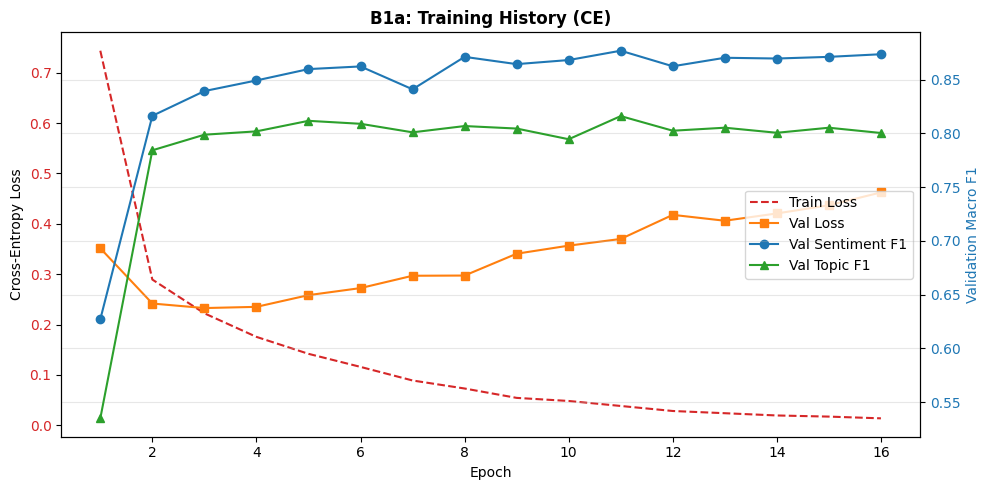


Chấn đoán trên validation === B1a_Hard_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9460    0.9688    0.9573       705
     Neutral     0.7833    0.6438    0.7068        73
    Positive     0.9688    0.9640    0.9664       805

    accuracy                         0.9514      1583
   macro avg     0.8994    0.8589    0.8768      1583
weighted avg     0.9501    0.9514    0.9503      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9356    0.9461    0.9408      1151
    Training     0.7803    0.7715    0.7759       267
    Facility     0.9178    0.9571    0.9371        70
      Others     0.6585    0.5684    0.6102        95

    accuracy                         0.8945      1583
   macro avg     0.8231    0.8108    0.8160      1583
weighted avg     0.8920    0.8945    0.8930      1583


=== B1a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9428

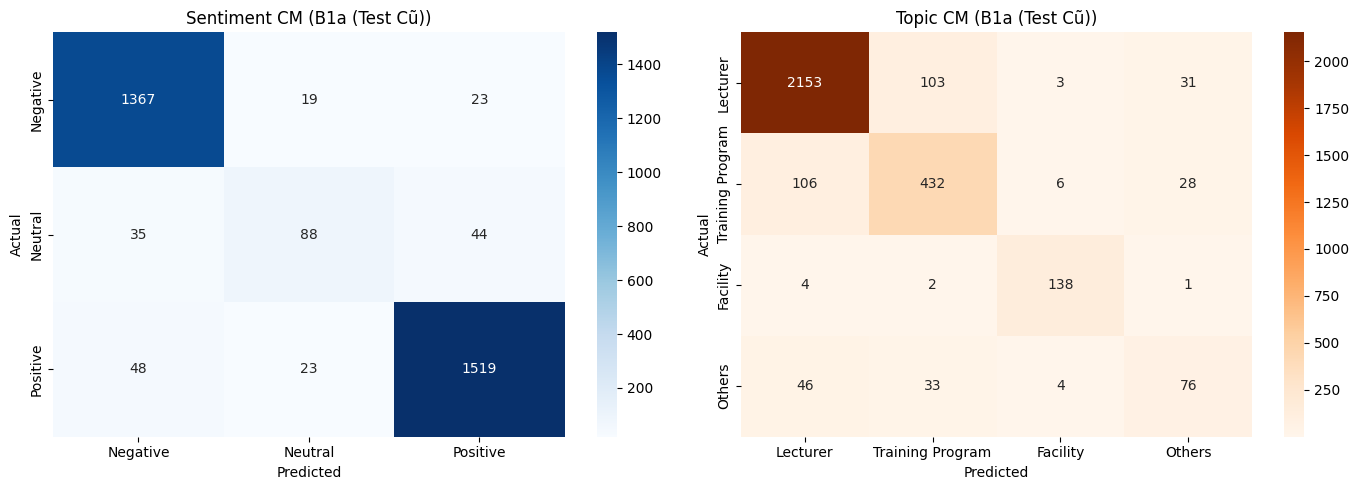


=== B1a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9503    0.9829    0.9663      1402
     Neutral     0.7077    0.5823    0.6389       158
    Positive     0.9805    0.9682    0.9743      1606

    accuracy                         0.9555      3166
   macro avg     0.8795    0.8445    0.8598      3166
weighted avg     0.9535    0.9555    0.9540      3166


=== B1a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9489    0.9555    0.9522      2293
Training Program     0.8386    0.8088    0.8234       591
        Facility     0.9470    0.9795    0.9630       146
          Others     0.6029    0.6029    0.6029       136

        accuracy                         0.9141      3166
       macro avg     0.8344    0.8367    0.8354      3166
    weighted avg     0.9134    0.9141    0.9137      3166



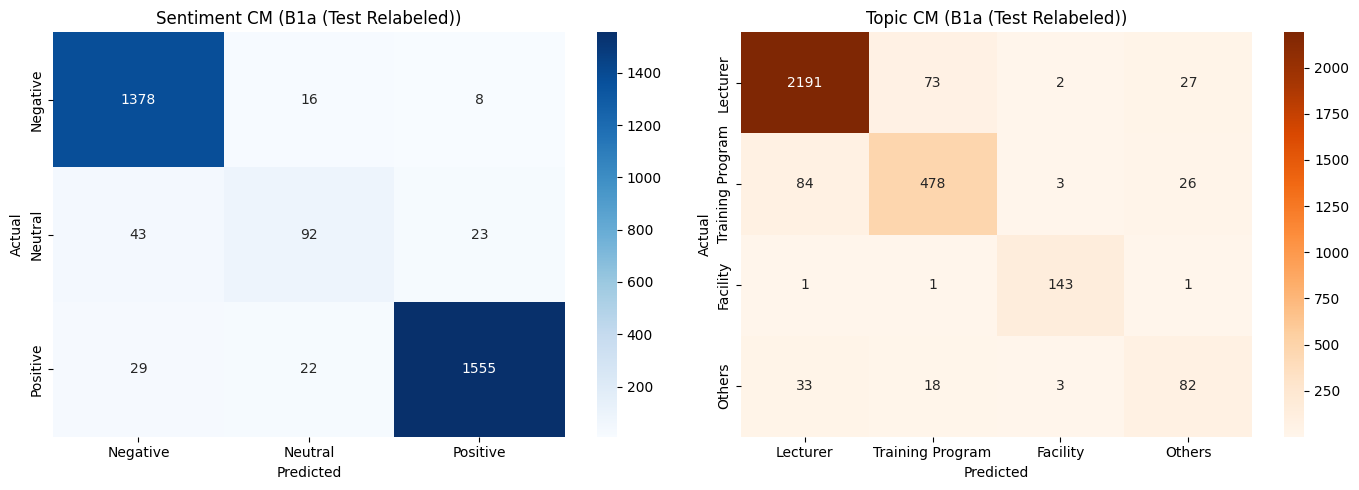


B2a: MTL Cross-Task Attention + Standard CE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.6795 | Val Loss: 0.3385 | Val Sent F1: 0.7145 | Val Topic F1: 0.6521 | Avg Val F1: 0.6833
New best (Avg Val F1: 0.6833)
Epoch 02 | Train Loss: 0.3127 | Val Loss: 0.2826 | Val Sent F1: 0.8248 | Val Topic F1: 0.7764 | Avg Val F1: 0.8006
New best (Avg Val F1: 0.8006)
Epoch 03 | Train Loss: 0.2408 | Val Loss: 0.2516 | Val Sent F1: 0.8422 | Val Topic F1: 0.8051 | Avg Val F1: 0.8236
New best (Avg Val F1: 0.8236)
Epoch 04 | Train Loss: 0.1887 | Val Loss: 0.2568 | Val Sent F1: 0.8311 | Val Topic F1: 0.7936 | Avg Val F1: 0.8124
Không cải thiện 1/5
Epoch 05 | Train Loss: 0.1525 | Val Loss: 0.2911 | Val Sent F1: 0.8377 | Val Topic F1: 0.7959 | Avg Val F1: 0.8168
Không cải thiện 2/5
Epoch 06 | Train Loss: 0.1243 | Val Loss: 0.3122 | Val Sent F1: 0.8409 | Val Topic F1: 0.7981 | Avg Val F1: 0.8195
Không cải thiện 3/5
Epoch 07 | Train Loss: 0.1023 | Val Loss: 0.3331 | Val Sent F1: 0.8621 | Val Topic F1: 0.7916 | Avg Val F1: 0.8268
New best (Avg Val F1: 0.8268)
Epoch 08 | Trai

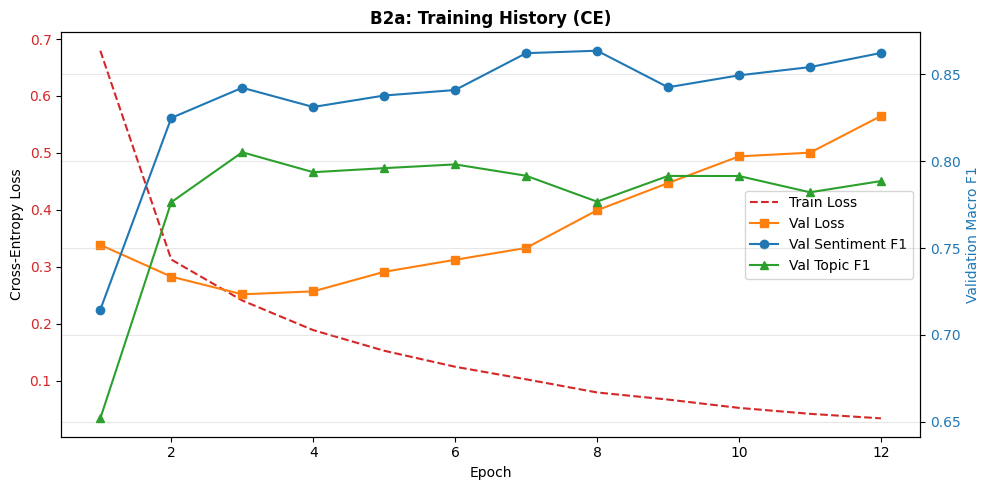


Chấn đoán trên validation === B2a_Cross_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9577    0.9631    0.9604       705
     Neutral     0.7544    0.5890    0.6615        73
    Positive     0.9572    0.9714    0.9642       805

    accuracy                         0.9501      1583
   macro avg     0.8897    0.8412    0.8621      1583
weighted avg     0.9480    0.9501    0.9486      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9245    0.9470    0.9356      1151
    Training     0.7509    0.7453    0.7481       267
    Facility     0.9403    0.9000    0.9197        70
      Others     0.6528    0.4947    0.5629        95

    accuracy                         0.8838      1583
   macro avg     0.8171    0.7718    0.7916      1583
weighted avg     0.8796    0.8838    0.8809      1583


=== B2a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.946

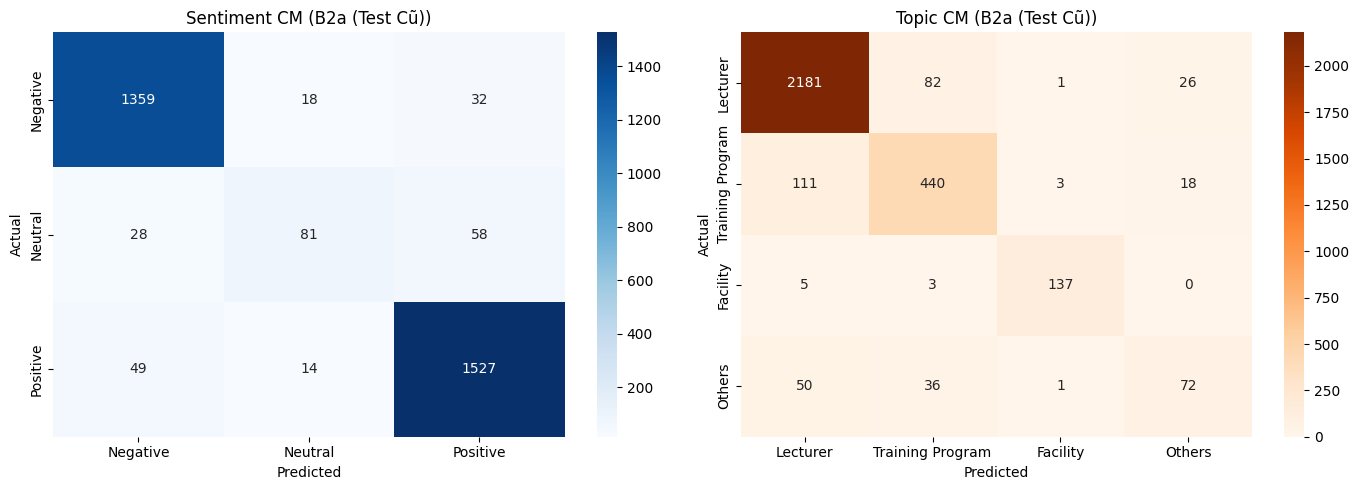


=== B2a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9547    0.9779    0.9662      1402
     Neutral     0.7522    0.5380    0.6273       158
    Positive     0.9666    0.9732    0.9699      1606

    accuracy                         0.9536      3166
   macro avg     0.8912    0.8297    0.8545      3166
weighted avg     0.9506    0.9536    0.9512      3166


=== B2a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9472    0.9695    0.9582      2293
Training Program     0.8681    0.8240    0.8455       591
        Facility     0.9859    0.9589    0.9722       146
          Others     0.6897    0.5882    0.6349       136

        accuracy                         0.9255      3166
       macro avg     0.8727    0.8352    0.8527      3166
    weighted avg     0.9231    0.9255    0.9239      3166



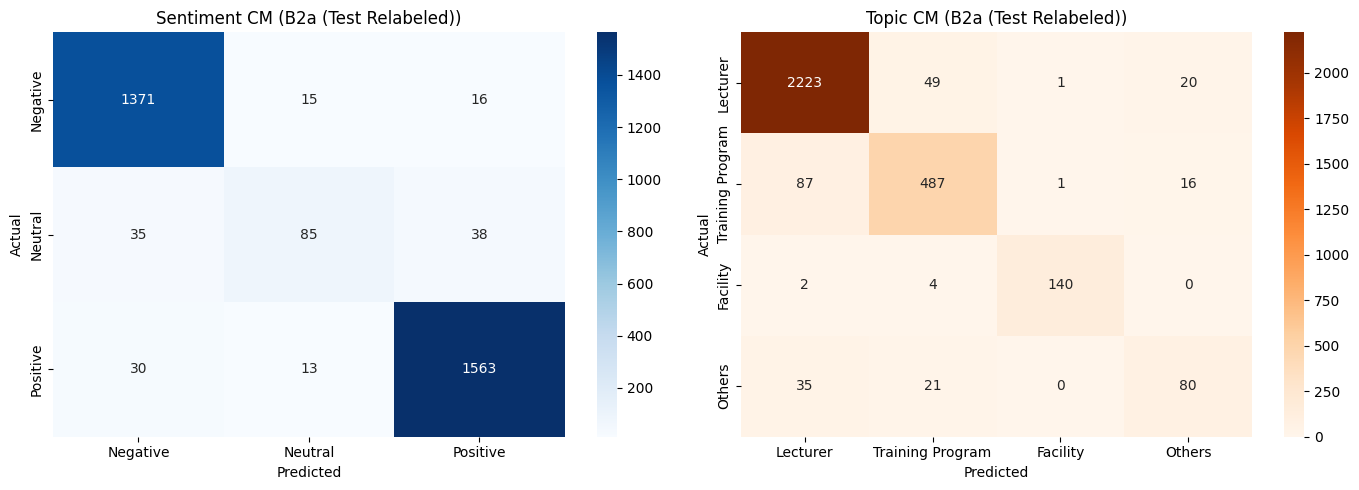


B3a: MTL Soft Sharing + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.7702 | Val Loss: 0.3670 | Val Sent F1: 0.6252 | Val Topic F1: 0.4092 | Avg Val F1: 0.5172
New best (Avg Val F1: 0.5172)
Epoch 02 | Train Loss: 0.2958 | Val Loss: 0.2526 | Val Sent F1: 0.8045 | Val Topic F1: 0.7370 | Avg Val F1: 0.7708
New best (Avg Val F1: 0.7708)
Epoch 03 | Train Loss: 0.2209 | Val Loss: 0.2327 | Val Sent F1: 0.8309 | Val Topic F1: 0.7940 | Avg Val F1: 0.8125
New best (Avg Val F1: 0.8125)
Epoch 04 | Train Loss: 0.1763 | Val Loss: 0.2342 | Val Sent F1: 0.8472 | Val Topic F1: 0.8095 | Avg Val F1: 0.8284
New best (Avg Val F1: 0.8284)
Epoch 05 | Train Loss: 0.1401 | Val Loss: 0.2627 | Val Sent F1: 0.8493 | Val Topic F1: 0.8162 | Avg Val F1: 0.8328
New best (Avg Val F1: 0.8328)
Epoch 06 | Train Loss: 0.1106 | Val Loss: 0.2744 | Val Sent F1: 0.8649 | Val Topic F1: 0.8085 | Avg Val F1: 0.8367
New best (Avg Val F1: 0.8367)
Epoch 07 | Train Loss: 0.0887 | Val Loss: 0.3026 | Val Sent F1: 0.8592 | Val Topic F1: 0.8023 | Avg Val F1: 0.8307
Không cải thiện

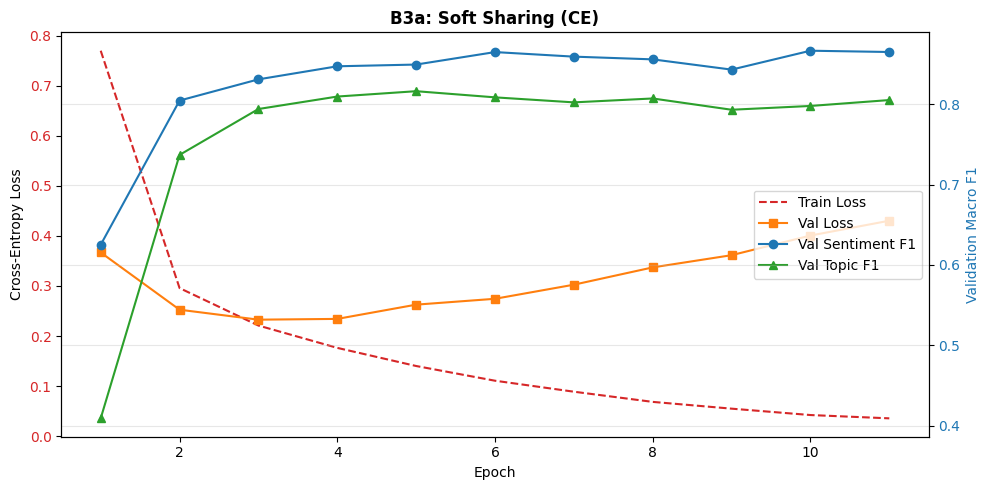


Chấn đoán trên validation === B3a_Soft_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9575    0.9589    0.9582       705
     Neutral     0.8077    0.5753    0.6720        73
    Positive     0.9527    0.9764    0.9644       805

    accuracy                         0.9501      1583
   macro avg     0.9060    0.8369    0.8649      1583
weighted avg     0.9482    0.9501    0.9482      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9309    0.9487    0.9398      1151
    Training     0.7778    0.7603    0.7689       267
    Facility     0.9697    0.9143    0.9412        70
      Others     0.6265    0.5474    0.5843        95

    accuracy                         0.8913      1583
   macro avg     0.8262    0.7927    0.8085      1583
weighted avg     0.8886    0.8913    0.8897      1583


=== B3a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9510

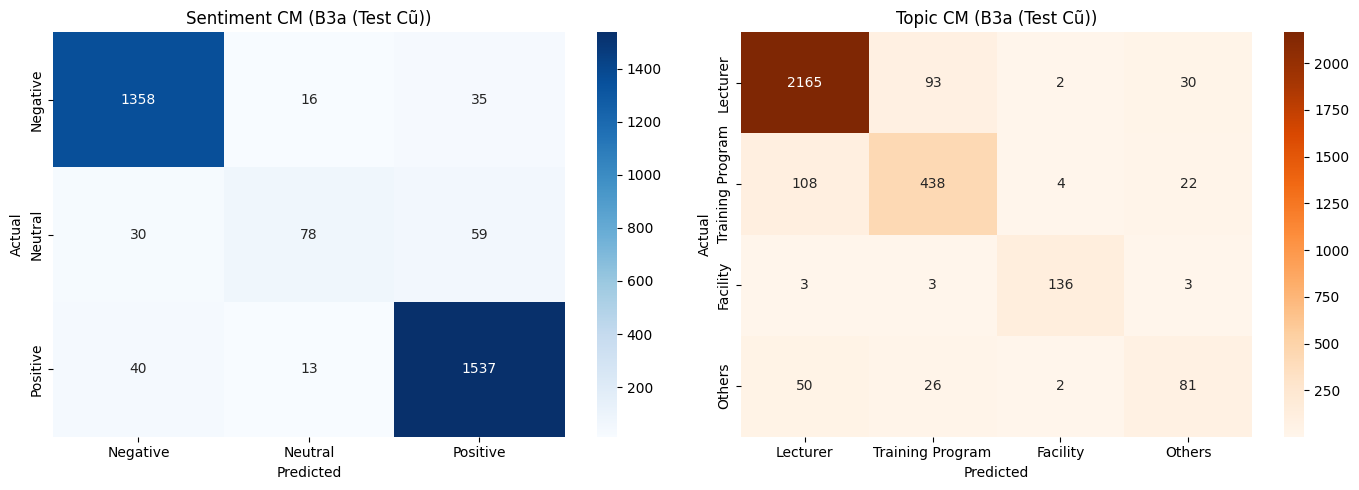


=== B3a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9608    0.9786    0.9696      1402
     Neutral     0.8037    0.5443    0.6491       158
    Positive     0.9657    0.9807    0.9731      1606

    accuracy                         0.9580      3166
   macro avg     0.9101    0.8345    0.8639      3166
weighted avg     0.9554    0.9580    0.9554      3166


=== B3a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9484    0.9621    0.9552      2293
Training Program     0.8661    0.8206    0.8427       591
        Facility     0.9653    0.9521    0.9586       146
          Others     0.6544    0.6544    0.6544       136

        accuracy                         0.9220      3166
       macro avg     0.8585    0.8473    0.8527      3166
    weighted avg     0.9212    0.9220    0.9214      3166



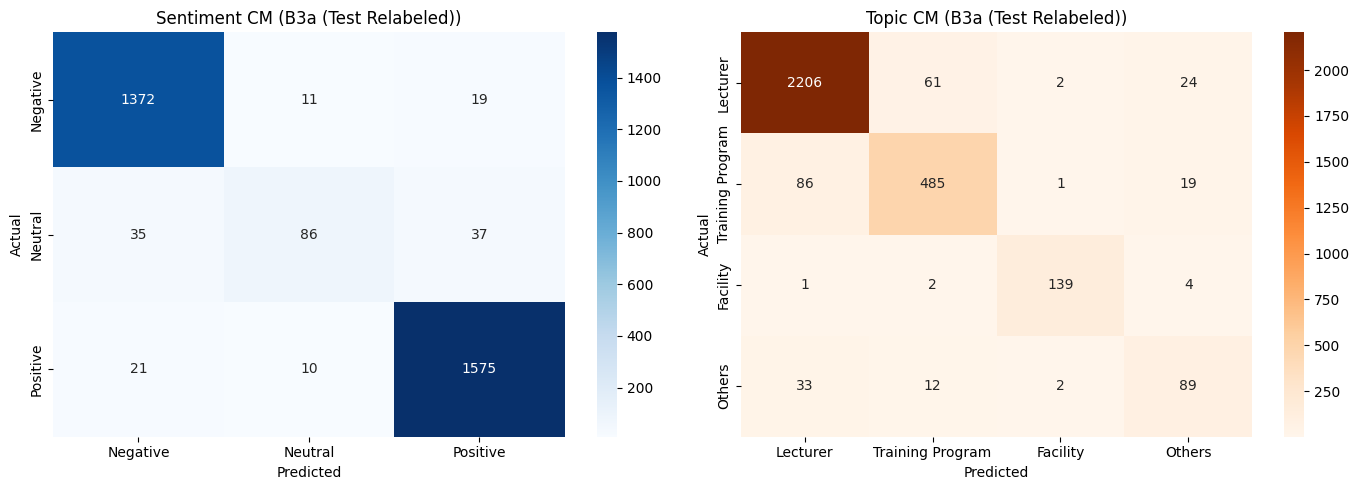


B4a: MMoE (Mixture-of-Experts) + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.8624 | Val Loss: 0.4070 | Val Sent F1: 0.6216 | Val Topic F1: 0.3364 | Avg Val F1: 0.4790
New best (Avg Val F1: 0.4790)
Epoch 02 | Train Loss: 0.3272 | Val Loss: 0.2541 | Val Sent F1: 0.7890 | Val Topic F1: 0.7578 | Avg Val F1: 0.7734
New best (Avg Val F1: 0.7734)
Epoch 03 | Train Loss: 0.2287 | Val Loss: 0.2356 | Val Sent F1: 0.8552 | Val Topic F1: 0.7891 | Avg Val F1: 0.8221
New best (Avg Val F1: 0.8221)
Epoch 04 | Train Loss: 0.1834 | Val Loss: 0.2607 | Val Sent F1: 0.8421 | Val Topic F1: 0.7960 | Avg Val F1: 0.8190
Không cải thiện 1/5
Epoch 05 | Train Loss: 0.1435 | Val Loss: 0.2817 | Val Sent F1: 0.8613 | Val Topic F1: 0.8028 | Avg Val F1: 0.8321
New best (Avg Val F1: 0.8321)
Epoch 06 | Train Loss: 0.1149 | Val Loss: 0.2945 | Val Sent F1: 0.8605 | Val Topic F1: 0.8022 | Avg Val F1: 0.8314
Không cải thiện 1/5
Epoch 07 | Train Loss: 0.0926 | Val Loss: 0.3327 | Val Sent F1: 0.8565 | Val Topic F1: 0.7876 | Avg Val F1: 0.8221
Không cải thiện 2/5
Epoch 08 | Trai

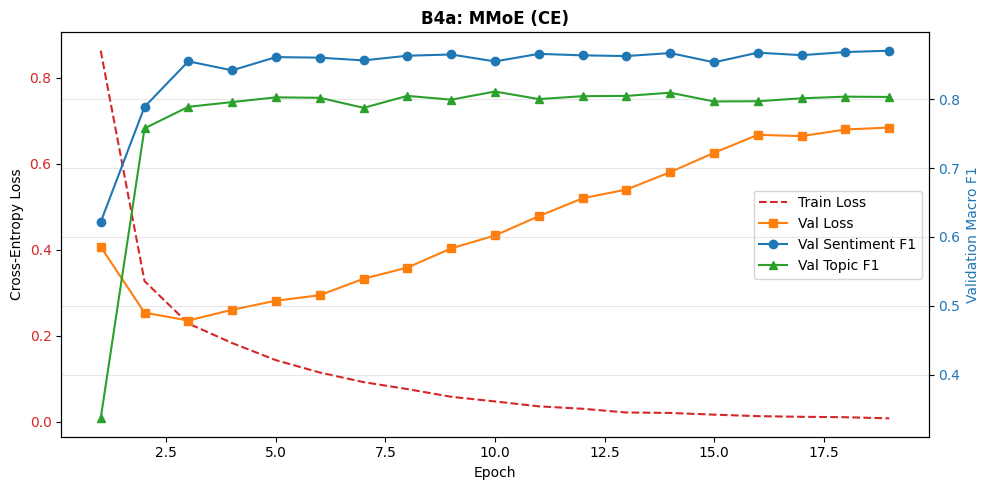


Chấn đoán trên validation === B4a_MMoE_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9537    0.9631    0.9584       705
     Neutral     0.7500    0.6164    0.6767        73
    Positive     0.9630    0.9702    0.9666       805

    accuracy                         0.9507      1583
   macro avg     0.8889    0.8499    0.8672      1583
weighted avg     0.9490    0.9507    0.9496      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9465    0.9374    0.9419      1151
    Training     0.7458    0.8240    0.7829       267
    Facility     0.9559    0.9286    0.9420        70
      Others     0.6250    0.5263    0.5714        95

    accuracy                         0.8932      1583
   macro avg     0.8183    0.8041    0.8096      1583
weighted avg     0.8938    0.8932    0.8929      1583


=== B4a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9392

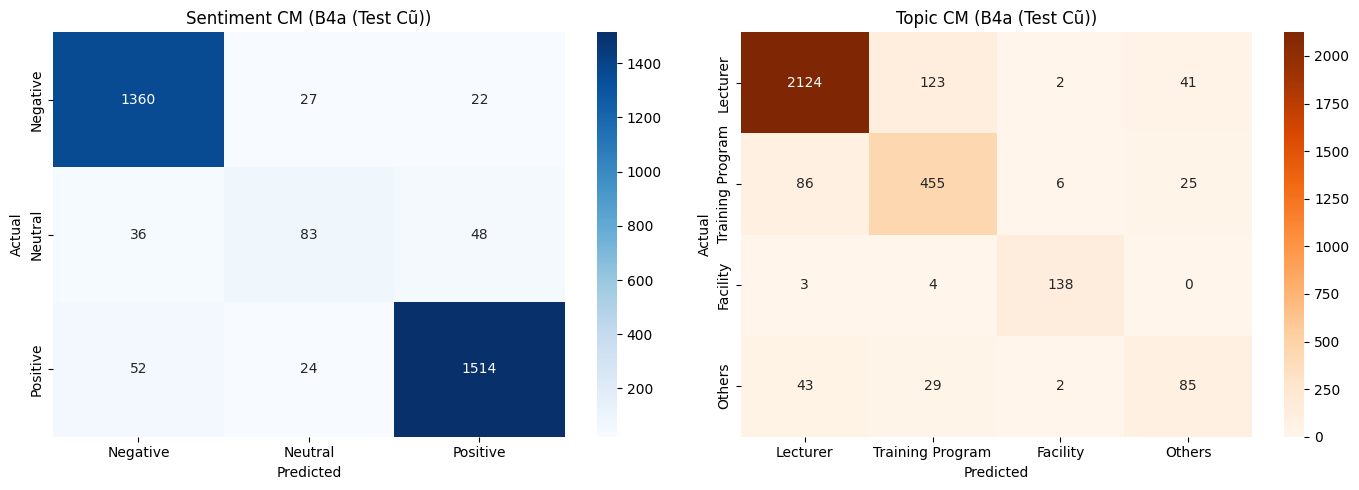


=== B4a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9482    0.9793    0.9635      1402
     Neutral     0.6866    0.5823    0.6301       158
    Positive     0.9811    0.9676    0.9743      1606

    accuracy                         0.9536      3166
   macro avg     0.8719    0.8431    0.8560      3166
weighted avg     0.9518    0.9536    0.9523      3166


=== B4a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9605    0.9451    0.9527      2293
Training Program     0.8249    0.8528    0.8386       591
        Facility     0.9595    0.9726    0.9660       146
          Others     0.5960    0.6618    0.6272       136

        accuracy                         0.9169      3166
       macro avg     0.8352    0.8581    0.8461      3166
    weighted avg     0.9195    0.9169    0.9181      3166



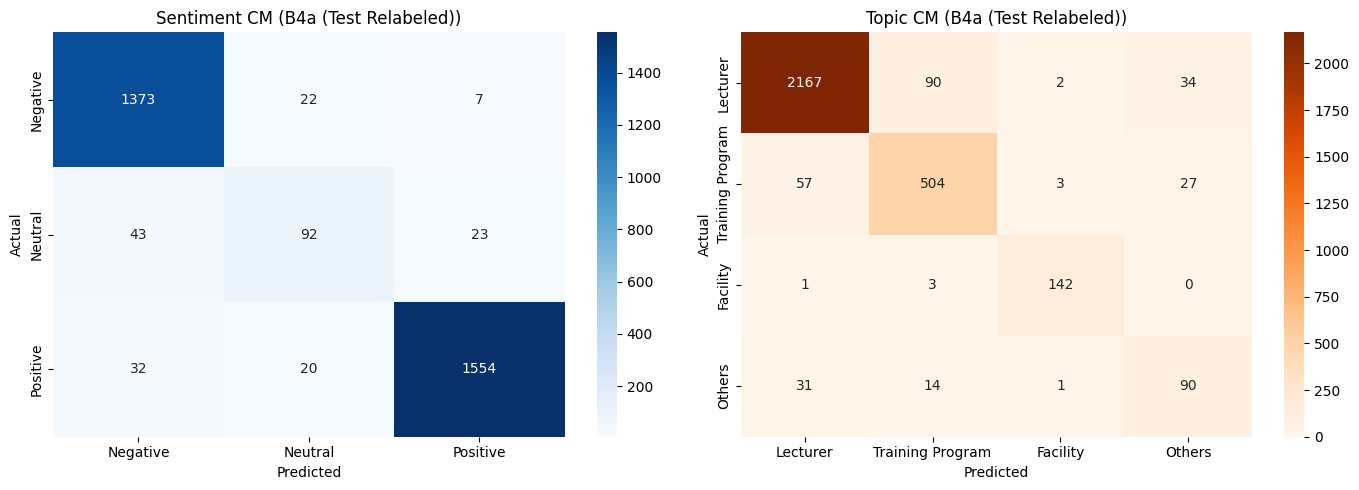


B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.7741 | Val Loss: 0.3648 | Sent F1: 0.6221 | Topic F1: 0.4027 | Avg F1: 0.5124
  ↑ New best Avg F1: 0.5124
Epoch 02 | Train Loss: 0.2925 | Val Loss: 0.2248 | Sent F1: 0.8347 | Topic F1: 0.8167 | Avg F1: 0.8257
  ↑ New best Avg F1: 0.8257
Epoch 03 | Train Loss: 0.2178 | Val Loss: 0.2368 | Sent F1: 0.8324 | Topic F1: 0.7939 | Avg F1: 0.8131
  No improve 1/5
Epoch 04 | Train Loss: 0.1764 | Val Loss: 0.2313 | Sent F1: 0.8557 | Topic F1: 0.8246 | Avg F1: 0.8401
  ↑ New best Avg F1: 0.8401
Epoch 05 | Train Loss: 0.1425 | Val Loss: 0.2565 | Sent F1: 0.8304 | Topic F1: 0.8131 | Avg F1: 0.8218
  No improve 1/5
Epoch 06 | Train Loss: 0.1150 | Val Loss: 0.2686 | Sent F1: 0.8555 | Topic F1: 0.8107 | Avg F1: 0.8331
  No improve 2/5
Epoch 07 | Train Loss: 0.0929 | Val Loss: 0.2780 | Sent F1: 0.8760 | Topic F1: 0.8084 | Avg F1: 0.8422
  ↑ New best Avg F1: 0.8422
Epoch 08 | Train Loss: 0.0719 | Val Loss: 0.3211 | Sent F1: 0.8360 | Topic F1: 0.7988 | Avg F1: 0.8174
  No improve 

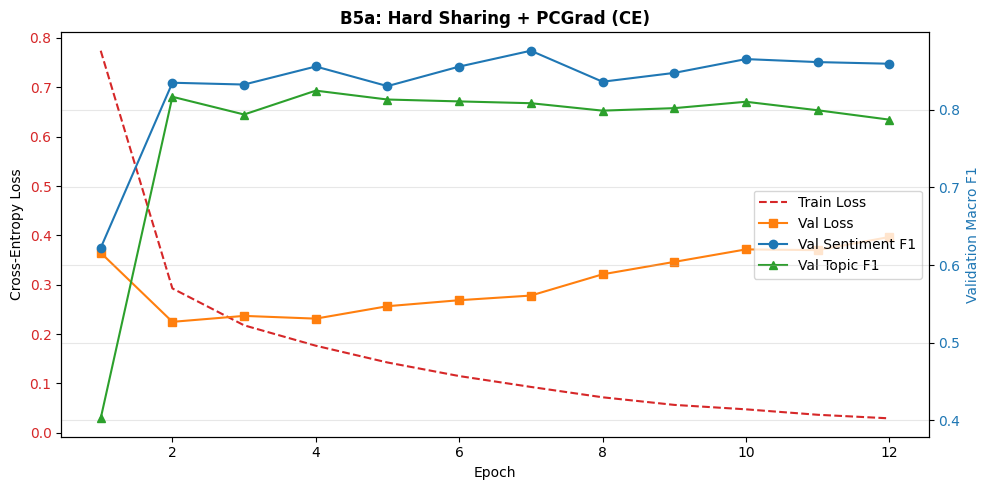


Chấn đoán trên validation === B5a_Hard_PCGrad_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9464    0.9759    0.9609       705
     Neutral     0.7797    0.6301    0.6970        73
    Positive     0.9749    0.9652    0.9700       805

    accuracy                         0.9545      1583
   macro avg     0.9003    0.8571    0.8760      1583
weighted avg     0.9532    0.9545    0.9534      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9428    0.9453    0.9440      1151
    Training     0.7448    0.8090    0.7756       267
    Facility     0.9286    0.9286    0.9286        70
      Others     0.6957    0.5053    0.5854        95

    accuracy                         0.8951      1583
   macro avg     0.8280    0.7970    0.8084      1583
weighted avg     0.8940    0.8951    0.8934      1583


=== B5a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative    

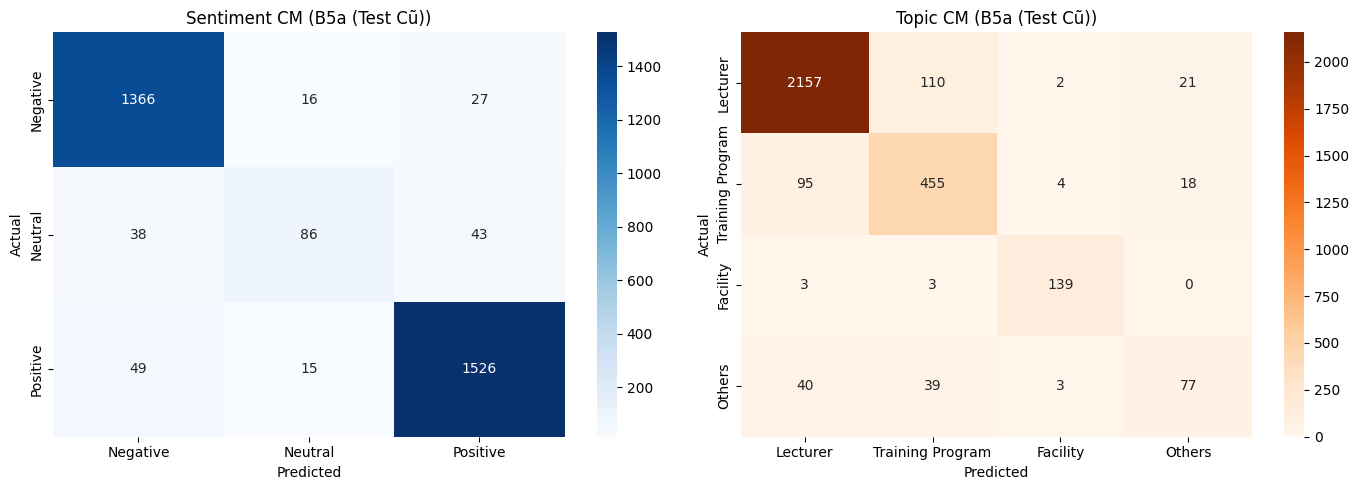


=== B5a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9484    0.9829    0.9653      1402
     Neutral     0.7607    0.5633    0.6473       158
    Positive     0.9793    0.9732    0.9763      1606

    accuracy                         0.9570      3166
   macro avg     0.8961    0.8398    0.8630      3166
weighted avg     0.9547    0.9570    0.9550      3166


=== B5a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9617    0.9625    0.9621      2293
Training Program     0.8418    0.8646    0.8531       591
        Facility     0.9662    0.9795    0.9728       146
          Others     0.7500    0.6397    0.6905       136

        accuracy                         0.9311      3166
       macro avg     0.8799    0.8616    0.8696      3166
    weighted avg     0.9304    0.9311    0.9306      3166



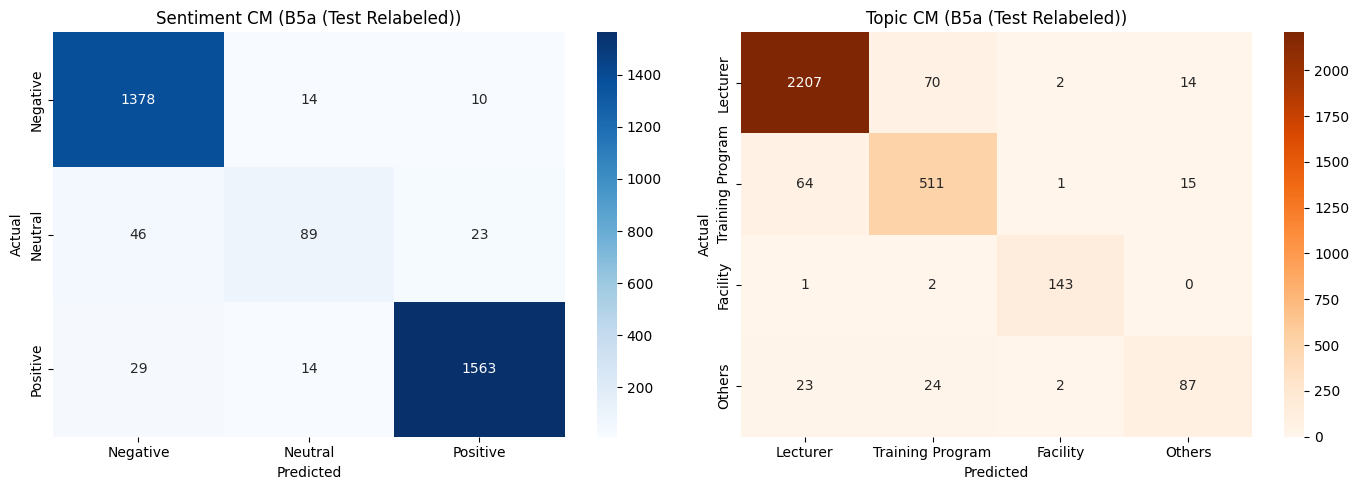


B6a: MTL Soft Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.7582 | Val Loss: 0.3633 | Sent F1: 0.6261 | Topic F1: 0.3761 | Avg F1: 0.5011
  ↑ New best Avg F1: 0.5011
Epoch 02 | Train Loss: 0.2909 | Val Loss: 0.2427 | Sent F1: 0.8132 | Topic F1: 0.7785 | Avg F1: 0.7958
  ↑ New best Avg F1: 0.7958
Epoch 03 | Train Loss: 0.2167 | Val Loss: 0.2344 | Sent F1: 0.8504 | Topic F1: 0.8083 | Avg F1: 0.8293
  ↑ New best Avg F1: 0.8293
Epoch 04 | Train Loss: 0.1739 | Val Loss: 0.2645 | Sent F1: 0.8365 | Topic F1: 0.8054 | Avg F1: 0.8209
  No improve 1/5
Epoch 05 | Train Loss: 0.1403 | Val Loss: 0.2656 | Sent F1: 0.8625 | Topic F1: 0.8091 | Avg F1: 0.8358
  ↑ New best Avg F1: 0.8358
Epoch 06 | Train Loss: 0.1102 | Val Loss: 0.2909 | Sent F1: 0.8572 | Topic F1: 0.8151 | Avg F1: 0.8361
  ↑ New best Avg F1: 0.8361
Epoch 07 | Train Loss: 0.0874 | Val Loss: 0.3212 | Sent F1: 0.8557 | Topic F1: 0.8147 | Avg F1: 0.8352
  No improve 1/5
Epoch 08 | Train Loss: 0.0688 | Val Loss: 0.3626 | Sent F1: 0.8576 | Topic F1: 0.8152 | Avg F1: 0.8364
  

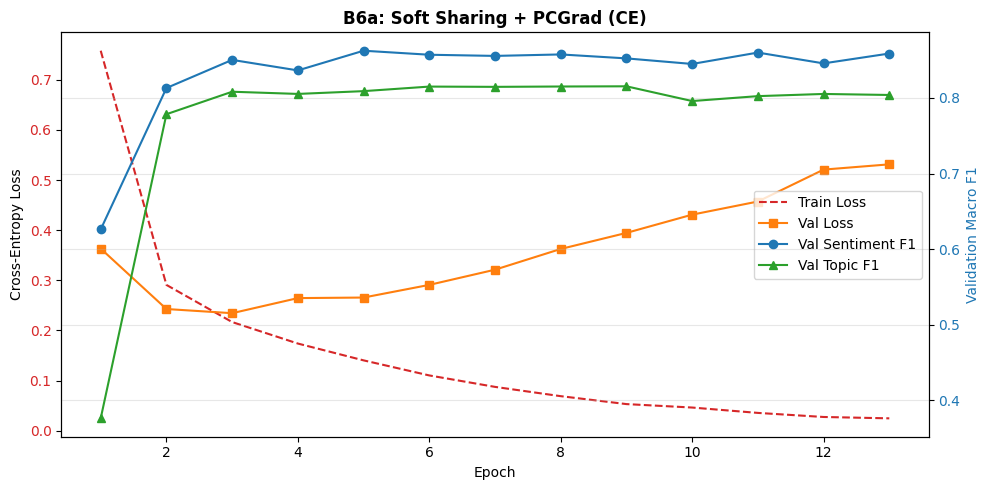


Chấn đoán trên validation === B6a_Soft_PCGrad_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9483    0.9631    0.9557       705
     Neutral     0.6620    0.6438    0.6528        73
    Positive     0.9698    0.9590    0.9644       805

    accuracy                         0.9463      1583
   macro avg     0.8600    0.8553    0.8576      1583
weighted avg     0.9461    0.9463    0.9461      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9379    0.9444    0.9411      1151
    Training     0.7545    0.7828    0.7684       267
    Facility     0.9559    0.9286    0.9420        70
      Others     0.6709    0.5579    0.6092        95

    accuracy                         0.8932      1583
   macro avg     0.8298    0.8034    0.8152      1583
weighted avg     0.8917    0.8932    0.8921      1583


=== B6a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative    

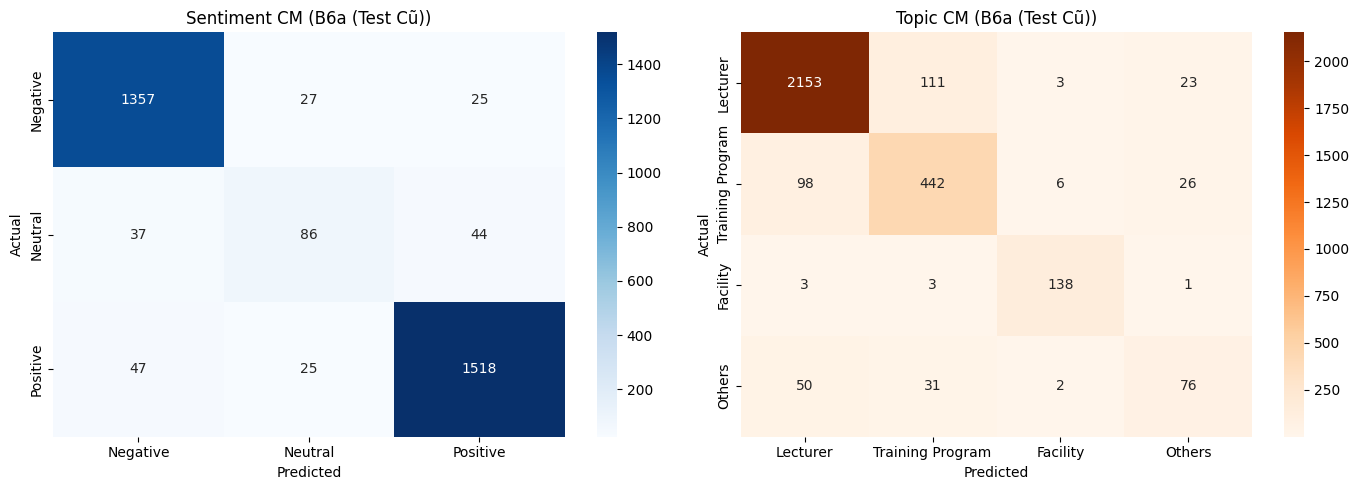


=== B6a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9500    0.9765    0.9631      1402
     Neutral     0.6667    0.5823    0.6216       158
    Positive     0.9805    0.9689    0.9746      1606

    accuracy                         0.9529      3166
   macro avg     0.8657    0.8425    0.8531      3166
weighted avg     0.9513    0.9529    0.9519      3166


=== B6a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9553    0.9599    0.9576      2293
Training Program     0.8467    0.8409    0.8438       591
        Facility     0.9530    0.9726    0.9627       146
          Others     0.6746    0.6250    0.6489       136

        accuracy                         0.9239      3166
       macro avg     0.8574    0.8496    0.8532      3166
    weighted avg     0.9229    0.9239    0.9233      3166



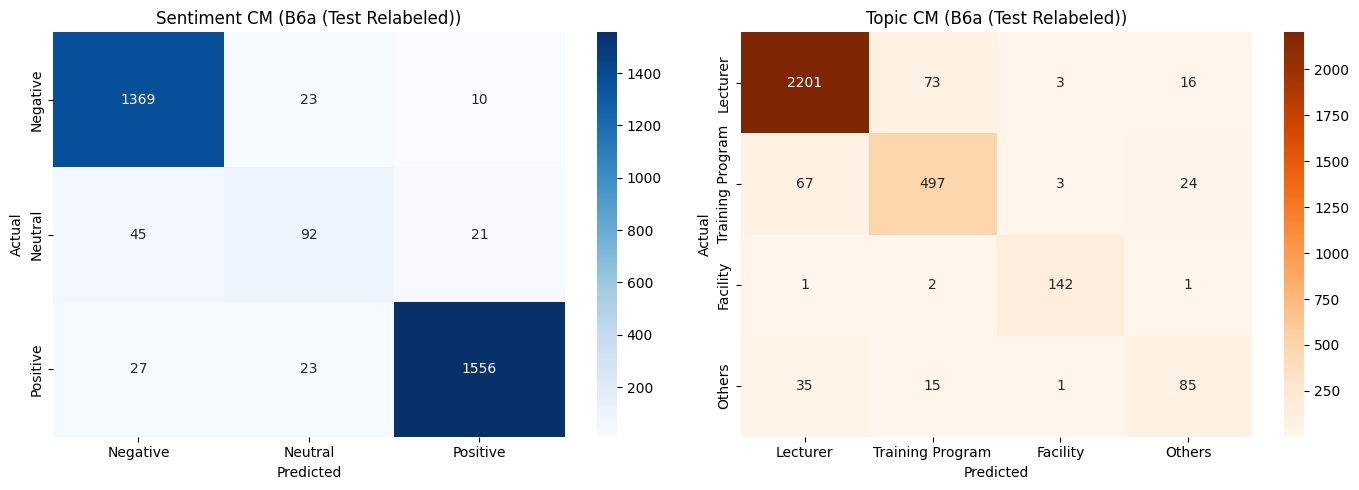


ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)
                    Avg Macro F1  Sent macro-F1  S-Negative  S-Neutral*  S-Positive  Topic macro-F1  T-Lecturer  T-Training  T-Facility*  T-Others*
Model                                                                                                                                              
B1a_Hard_CE               0.8101         0.8351      0.9563      0.5926      0.9565          0.7851      0.9363      0.7566       0.9324     0.5153
B2a_Cross_CE              0.8138         0.8287      0.9554      0.5786      0.9523          0.7989      0.9407      0.7767       0.9547     0.5236
B3a_Soft_CE               0.8138         0.8270      0.9573      0.5693      0.9544          0.8006      0.9380      0.7739       0.9412     0.5492
B4a_MMoE_CE               0.8088         0.8192      0.9520      0.5515      0.9540          0.7985      0.9344      0.7692       0.9420     0.5484
B5a_Hard_PCGrad_CE        0.8224         0.8394      0

In [ ]:
# CHẠY THỰC NGHIỆM & ĐÁNH GIÁ TRÊN 2 TẬP TEST
results_old_test = {}
results_new_test = {}

# 1. Standard Cross Entropy (CE)
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

# 2. Weighted Cross Entropy (WCE) - Tích hợp Class Weights
wce_sent  = nn.CrossEntropyLoss(weight=sent_weights.to(DEVICE))
wce_topic = nn.CrossEntropyLoss(weight=topic_weights.to(DEVICE))

# 3. Focal Loss
focal_sent  = FocalLoss(alpha=sent_focal_alpha,  gamma=2.0).to(DEVICE)
focal_topic = FocalLoss(alpha=topic_focal_alpha, gamma=3.0).to(DEVICE)

# 4. Asymmetric Loss (ASL)
asl_sent = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 4.0, 0.0],  
    gamma_pos_list=[2.0, 1.0, 2.0]   
).to(DEVICE)

asl_topic = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 0.0, 0.0, 4.0], 
    gamma_pos_list=[2.0, 2.0, 2.0, 1.0]
).to(DEVICE)

# ── B1a: MTL Hard Sharing + Standard CE ──
print("\n" + "="*50)
print("B1a: MTL Hard Sharing + Standard CE")
print("="*50)
model_b1a = MTLHardSharing(dropout=0.3).to(DEVICE)
model_b1a, hist_b1a, val_f1_b1a = train_mtl(model_b1a, train_loader, val_loader, 
                                            ce_sent, ce_topic, model_name="B1a_Hard_CE")
plot_mtl_history(hist_b1a, title="B1a: Training History (CE)")
diagnose_validation(model_b1a, val_loader, "B1a_Hard_CE")
results_old_test["B1a_Hard_CE"] = evaluate_and_plot_mtl(model_b1a, test_loader, title_prefix="B1a (Test Cũ)")
results_new_test["B1a_Hard_CE"] = evaluate_and_plot_mtl(model_b1a, test_loader1, title_prefix="B1a (Test Relabeled)")


# ── B2a: MTL Cross-Task Attention + Standard CE ──
print("\n" + "="*50)
print("B2a: MTL Cross-Task Attention + Standard CE")
print("="*50)
model_b2a = MTLCrossTask(dropout=0.3, head_dropout=0.3).to(DEVICE)
model_b2a, hist_b2a, val_f1_b2a = train_mtl(model_b2a, train_loader, val_loader, 
                                            ce_sent, ce_topic, model_name="B2a_Cross_CE")
plot_mtl_history(hist_b2a, title="B2a: Training History (CE)")
diagnose_validation(model_b2a, val_loader, "B2a_Cross_CE")
results_old_test["B2a_Cross_CE"] = evaluate_and_plot_mtl(model_b2a, test_loader, title_prefix="B2a (Test Cũ)")
results_new_test["B2a_Cross_CE"] = evaluate_and_plot_mtl(model_b2a, test_loader1, title_prefix="B2a (Test Relabeled)")

# ── B3a: MTL Soft Sharing + Standard CE ──
print("\n" + "="*60)
print("B3a: MTL Soft Sharing + Standard CE (Lambda 0.6/0.4)")
print("="*60)
model_b3a = MTLSoftSharing(dropout=0.3).to(DEVICE)
model_b3a, hist_b3a, val_f1_b3a = train_mtl(model_b3a, train_loader, val_loader, 
                                            ce_sent, ce_topic, 
                                            lambda_s=0.6, lambda_t=0.4, 
                                            model_name="B3a_Soft_CE")
plot_mtl_history(hist_b3a, title="B3a: Soft Sharing (CE)")
diagnose_validation(model_b3a, val_loader, "B3a_Soft_CE")
results_old_test["B3a_Soft_CE"] = evaluate_and_plot_mtl(model_b3a, test_loader, title_prefix="B3a (Test Cũ)")
results_new_test["B3a_Soft_CE"] = evaluate_and_plot_mtl(model_b3a, test_loader1, title_prefix="B3a (Test Relabeled)")


# ── B4a: MMoE + Standard CE ──
print("\n" + "="*60)
print("B4a: MMoE (Mixture-of-Experts) + Standard CE (Lambda 0.6/0.4)")
print("="*60)
model_b4a = MMoE_PhoBERT().to(DEVICE)
model_b4a, hist_b4a, val_f1_b4a = train_mtl(model_b4a, train_loader, val_loader, 
                                            ce_sent, ce_topic, 
                                            lambda_s=0.6, lambda_t=0.4, 
                                            model_name="B4a_MMoE_CE")
plot_mtl_history(hist_b4a, title="B4a: MMoE (CE)")
diagnose_validation(model_b4a, val_loader, "B4a_MMoE_CE")
results_old_test["B4a_MMoE_CE"] = evaluate_and_plot_mtl(model_b4a, test_loader, title_prefix="B4a (Test Cũ)")
results_new_test["B4a_MMoE_CE"] = evaluate_and_plot_mtl(model_b4a, test_loader1, title_prefix="B4a (Test Relabeled)")

# ── B5a: MTL Hard Sharing + PCGrad + Standard CE ──
print("\n" + "="*60)
print("B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)")
print("="*60)

# 1. Khởi tạo đúng mô hình và biến
model_b5a = MTLHardSharing(dropout=0.3).to(DEVICE)

# 2. Gọi hàm train_pcgrad thay vì train_mtl
model_b5a, hist_b5a, val_f1_b5a = train_pcgrad(
    model=model_b5a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=ce_sent,      # Chú ý tên tham số của hàm PCGrad
    loss_topic_fn=ce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B5a_Hard_PCGrad_CE"
)

# 3. Đánh giá và lưu kết quả với đúng tên biến B5a
plot_mtl_history(hist_b5a, title="B5a: Hard Sharing + PCGrad (CE)")
diagnose_validation(model_b5a, val_loader, "B5a_Hard_PCGrad_CE") 
results_old_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader, title_prefix="B5a (Test Cũ)")
results_new_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader1, title_prefix="B5a (Test Relabeled)")


# ── B6a: MTL Soft Sharing + PCGrad + Standard CE ──
print("\n" + "="*60)
print("B6a: MTL Soft Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)")
print("="*60)

# 1. Khởi tạo đúng mô hình và biến
model_b6a = MTLSoftSharing(dropout=0.3).to(DEVICE)

# 2. Gọi hàm train_pcgrad
model_b6a, hist_b6a, val_f1_b6a = train_pcgrad(
    model=model_b6a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=ce_sent, 
    loss_topic_fn=ce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B6a_Soft_PCGrad_CE"
)

# 3. Đánh giá và lưu kết quả với đúng tên biến B6a
plot_mtl_history(hist_b6a, title="B6a: Soft Sharing + PCGrad (CE)")
diagnose_validation(model_b6a, val_loader, "B6a_Soft_PCGrad_CE") 
results_old_test["B6a_Soft_PCGrad_CE"] = evaluate_and_plot_mtl(model_b6a, test_loader, title_prefix="B6a (Test Cũ)")
results_new_test["B6a_Soft_PCGrad_CE"] = evaluate_and_plot_mtl(model_b6a, test_loader1, title_prefix="B6a (Test Relabeled)")

# 6. IN BẢNG SO SÁNH KẾT QUẢ CHO CẢ 2 TEST SET
def extract_per_class_f1(report, classes):
    return {c: round(report[c]["f1-score"], 4) for c in classes}

def generate_result_dataframe(results_dict):
    rows = []
    for name, res in results_dict.items():
        s_per = extract_per_class_f1(res["sent_report"], ["Negative","Neutral","Positive"])
        t_per = extract_per_class_f1(res["topic_report"], ["Lecturer","Training Program","Facility","Others"])
        rows.append({
            "Model":            name,
            "Avg Macro F1":     round((res["sent_macro_f1"] + res["topic_macro_f1"])/2, 4),
            "Sent macro-F1":    round(res["sent_macro_f1"], 4),
            "S-Negative":       s_per["Negative"],
            "S-Neutral*":       s_per["Neutral"],      
            "S-Positive":       s_per["Positive"],
            "Topic macro-F1":   round(res["topic_macro_f1"], 4),
            "T-Lecturer":       t_per["Lecturer"],
            "T-Training":       t_per["Training Program"],
            "T-Facility*":      t_per["Facility"],     
            "T-Others*":        t_per["Others"],       
        })
    return pd.DataFrame(rows).set_index("Model")

df_results_old = generate_result_dataframe(results_old_test)
df_results_new = generate_result_dataframe(results_new_test)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)")
print("=" * 110)
print(df_results_old.to_string())

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST ĐÃ SỬA NHÃN (RELABELED TEST SET)")
print("=" * 110)
print(df_results_new.to_string())
print("\n(*) Ghi chú: Các lớp có dấu * là lớp thiểu số mất cân bằng dữ liệu.")